In [1]:
# Importing necessary librareies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
# Feature selection
X = dataset.iloc[:, [3, 4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [5]:
# Model
from sklearn.cluster import OPTICS
model = OPTICS(min_samples=6,xi=0.05)
Y = model.fit_predict(X)
Y

array([-1,  4,  7,  4, -1,  4,  7, -1,  7,  4,  7, -1,  7,  4,  7,  4, -1,
        4, -1, -1, -1,  4,  7,  4,  7,  4, -1, -1, -1,  4,  7,  4,  7, -1,
        7,  4, -1,  4, -1,  4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,
       -1, -1, -1, -1, -1,  0, -1,  0,  0, -1,  0,  0, -1,  0, -1,  0,  0,
       -1,  0,  0, -1,  0, -1, -1,  1,  1, -1, -1, -1,  1,  1, -1, -1,  1,
       -1, -1,  1, -1,  2, -1,  3,  2,  3,  3, -1,  2,  2,  3,  2,  3,  2,
       -1, -1, -1,  3,  2,  2,  3,  2,  2, -1,  3,  2,  2,  2,  3, -1,  3,
       -1, -1, -1, -1,  9, -1,  8, -1,  9,  5,  8,  5,  8, -1,  8,  5,  9,
        5,  8,  5,  8,  5,  9, -1,  9,  5,  9, -1,  8, -1,  9, -1,  9,  5,
        8,  5,  9,  5,  8,  5,  8, -1, -1,  5,  9,  6, -1,  6,  9,  6, -1,
        6, -1, -1,  9,  6, -1,  6, -1,  6, -1, -1, -1,  6, -1, -1, -1,  6,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [6]:
# Adding the cluster group column to the dataframe
supervised = dataset
supervised["Cluster Group"]=Y
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster Group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,4
2,3,Female,20,16,6,7
3,4,Female,23,16,77,4
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


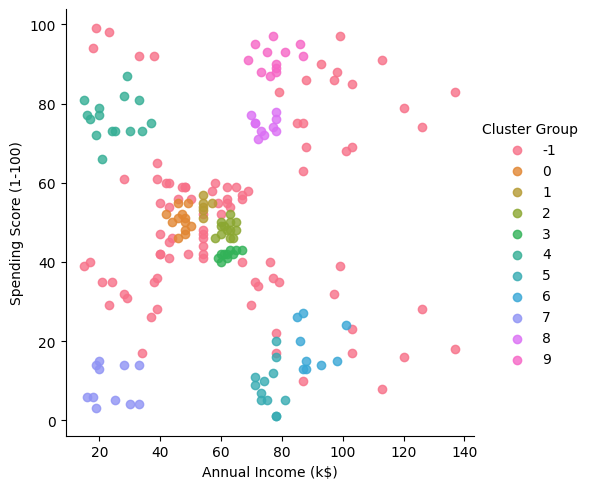

In [7]:
# Plotting the model
import seaborn as sns
plot = sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],
                  fit_reg=False,legend=True,legend_out=True)
plot